# Multi-task RuBERT for Russian NER and Relation-Type Classification

This notebook trains a shared Transformer encoder for two information-extraction tasks on Russian news texts:

1. **Named entity recognition (NER):** token-level BIO tagging.
2. **Document-level multi-label relation-type classification:** predicting which of 30 relation types are present in a document.

The project is an educational research prototype. It does **not** extract entity-pair relation triples, and it should not be described as a complete relation-extraction system. Its classification head predicts document-level relation-type presence only.

> **Reproducibility note:** This public version uses separate train, validation, and untouched test splits. Hyperparameters, thresholds, and model checkpoints are selected on the validation split; the external test split is evaluated once after selection.


## Dataset and Task Definition

The notebook loads the public `danasone/nerel` dataset from the Hugging Face Hub. It is derived from the Russian NEREL collection, which contains annotations for nested named entities, relations, and events. The original NEREL dataset defines 29 entity types and 49 relation types. This experiment uses its provided BIO token labels and a 30-label document-level multi-hot target representation. [1] [2]

For each document, the model produces:

- one BIO label for each first subword of an input word;
- a 30-dimensional vector of relation-type probabilities.

The shared encoder is `cointegrated/rubert-tiny2`. A token-classification head operates over contextualized token representations, while a second linear head operates on the encoder's first-token representation.


## Evaluation Design

The data is split with a fixed random seed into approximately 70% training, 15% validation, and 15% final test data. The validation split is used for learning-curve monitoring, model selection, and per-label threshold tuning. The final test split is not used until model selection is complete.

NER is reported with three distinct measures:

- **BIO token macro F1 (all labels):** includes the background `O` tag;
- **BIO token macro F1 (entity labels only):** excludes `O`;
- **entity-span F1:** calculated with `seqeval` on reconstructed BIO sequences.

The third measure is the most directly interpretable NER measure. The first two remain useful diagnostics, but they should not be compared directly with nested-NER benchmark scores from the original NEREL paper.


In [ ]:
import sys
!{sys.executable} -m pip install --upgrade pip setuptools
!{sys.executable} -m pip install seqeval

# Core dependencies
from collections import Counter
from pathlib import Path
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from datasets import load_dataset
from sklearn.metrics import classification_report, f1_score
from torch.optim import AdamW
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from transformers import (
    AutoModel,
    AutoTokenizer,
    DataCollatorForTokenClassification,
    get_linear_schedule_with_warmup
)
from seqeval.metrics import classification_report as seqeval_classification_report
from seqeval.metrics import f1_score as seqeval_f1_score

In [ ]:
# Reproducibility configuration
SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')


Using device: cuda
GPU: NVIDIA A100-SXM4-40GB


In [ ]:
# Load the public dataset
ds = load_dataset('danasone/nerel')['train']

print(f'Dataset size: {len(ds)} documents')
print(f'Columns: {ds.column_names}')
print('\nFirst record:')
print(ds[0])


In [ ]:
# Inspect BIO labels and document-level targets
all_tags = [tag for example in ds['tags'] for tag in example]
tag_counts = Counter(all_tags)
entity_types = sorted({tag.split('-', 1)[1] for tag in tag_counts if tag != 'O'})

print(f'BIO labels: {len(tag_counts)}')
print(f'Entity types: {len(entity_types)}')
print(f'Entity types: {entity_types}')
print('\nMost frequent BIO labels:')
for tag, count in tag_counts.most_common(15):
    print(f'{tag:25s} {count}')

characteristic_names = [
    'WORKPLACE', 'ALTERNATIVE_NAME', 'WORKS_AS', 'PARTICIPANT_IN',
    'POINT_IN_TIME', 'TAKES_PLACE_IN', 'HEADQUARTERED_IN', 'ORIGINS_FROM',
    'LOCATED_IN', 'AGENT', 'AGE_IS', 'HAS_CAUSE', 'PRODUCES',
    'AWARDED_WITH', 'PART_OF', 'IDEOLOGY_OF', 'MEMBER_OF', 'CONVICTED_OF',
    'INANIMATE_INVOLVED', 'SUBEVENT_OF', 'SUBORDINATE_OF', 'KNOWS',
    'MEDICAL_CONDITION', 'PARENT_OF', 'PLACE_RESIDES_IN', 'OWNER_OF',
    'ABBREVIATION', 'FOUNDED_BY', 'ORGANIZES', 'PENALIZED_AS',
]

cls_matrix = np.asarray(ds['cls_vec'])
positive_counts = cls_matrix.sum(axis=0)
positive_ratio = positive_counts / len(ds)

class_frequency = pd.DataFrame({
    'relation_type': characteristic_names,
    'positive_documents': positive_counts.astype(int),
    'positive_ratio': positive_ratio,
}).sort_values('positive_ratio', ascending=False)

display(class_frequency)
print(f'Average active document-level labels: {cls_matrix.sum(axis=1).mean():.2f}')


BIO labels: 58
Entity types: 29
Entity types: ['AGE', 'AWARD', 'CITY', 'COUNTRY', 'CRIME', 'DATE', 'DISEASE', 'DISTRICT', 'EVENT', 'FACILITY', 'FAMILY', 'IDEOLOGY', 'LANGUAGE', 'LAW', 'LOCATION', 'MONEY', 'NATIONALITY', 'NUMBER', 'ORDINAL', 'ORGANIZATION', 'PENALTY', 'PERCENT', 'PERSON', 'PRODUCT', 'PROFESSION', 'RELIGION', 'STATE_OR_PROVINCE', 'TIME', 'WORK_OF_ART']

Most frequent BIO labels:
O                         97660
B-PERSON                  7343
I-DATE                    7291
B-PROFESSION              5193
I-PROFESSION              4941
I-PERSON                  4871
B-EVENT                   4318
B-ORGANIZATION            3768
B-DATE                    3548
I-ORGANIZATION            3484
I-EVENT                   3347
B-COUNTRY                 1858
I-LAW                     1377
B-NUMBER                  1260
B-CITY                    1206


,relation_type,positive_documents,positive_ratio
1,ALTERNATIVE_NAME,723,0.969169
2,WORKS_AS,678,0.908847
3,PARTICIPANT_IN,656,0.879357
0,WORKPLACE,609,0.816354
4,POINT_IN_TIME,600,0.804290
5,TAKES_PLACE_IN,545,0.730563
10,AGE_IS,535,0.717158
6,HEADQUARTERED_IN,518,0.694370
8,LOCATED_IN,454,0.608579
7,ORIGINS_FROM,449,0.601877


Average active document-level labels: 11.96


count     746.000000
mean      221.292225
std       119.721547
min        62.000000
50%       201.500000
95%       358.000000
99%       619.350000
max      1710.000000
dtype: float64


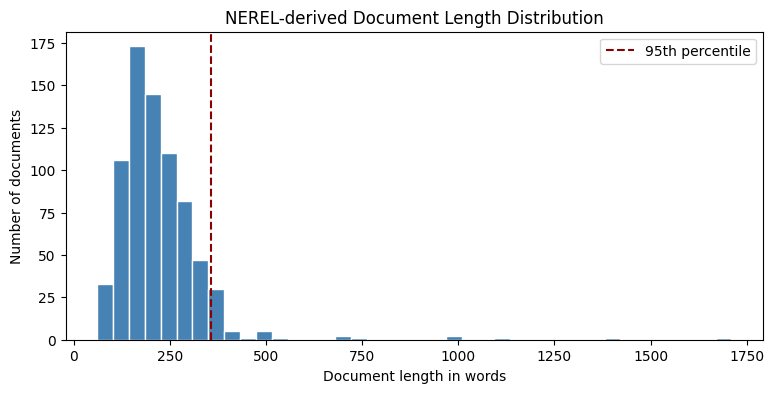

In [ ]:
# Explore document lengths before defining the maximum sequence length
lengths = np.asarray([len(tokens) for tokens in ds['tokens']])
print(pd.Series(lengths).describe(percentiles=[0.50, 0.95, 0.99]))

plt.figure(figsize=(9, 4))
plt.hist(lengths, bins=40, color='steelblue', edgecolor='white')
plt.axvline(np.quantile(lengths, 0.95), color='darkred', linestyle='--', label='95th percentile')
plt.xlabel('Document length in words')
plt.ylabel('Number of documents')
plt.title('NEREL-derived Document Length Distribution')
plt.legend()
plt.show()


## Tokenization and Split Construction

Fast-tokenizer word IDs are used to transfer word-level BIO labels to subword tokens. The first subword of every word receives the original label; padding and subsequent subwords receive `-100`, so that they are ignored by the token-classification loss and metric calculations.

The original dataset is divided before tokenization. This prevents a test split from being repeatedly consulted during training and model selection.


In [ ]:
MODEL_NAME = 'cointegrated/rubert-tiny2'
MAX_LENGTH = 512
BATCH_SIZE = 16

all_tags_flat = sorted({tag for example in ds['tags'] for tag in example})
label2id = {label: idx for idx, label in enumerate(all_tags_flat)}
id2label = {idx: label for label, idx in label2id.items()}
entity_label_ids = [idx for label, idx in label2id.items() if label != 'O']

print(f'Number of BIO labels, including O: {len(label2id)}')
print(label2id)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)


In [ ]:
# Approximate 70% / 15% / 15% document split using a fixed seed
# The data is not stratified because multilabel stratification is not provided by this dataset API.
first_split = ds.train_test_split(test_size=0.15, seed=SEED)
train_validation_raw = first_split['train']
test_raw = first_split['test']

validation_fraction_of_remainder = 0.15 / 0.85
second_split = train_validation_raw.train_test_split(
    test_size=validation_fraction_of_remainder,
    seed=SEED,
)
train_raw = second_split['train']
validation_raw = second_split['test']

print(f'Train documents:      {len(train_raw)}')
print(f'Validation documents: {len(validation_raw)}')
print(f'Test documents:       {len(test_raw)}')


Train documents:      522
Validation documents: 112
Test documents:       112


In [ ]:
def tokenize_and_align_labels(examples_batch):
    tokenized = tokenizer(
        examples_batch['tokens'],
        is_split_into_words=True,
        truncation=True,
        padding='max_length',
        max_length=MAX_LENGTH,
    )

    aligned_labels = []
    for batch_index, word_tags in enumerate(examples_batch['tags']):
        word_ids = tokenized.word_ids(batch_index=batch_index)
        label_ids = []
        previous_word_id = None

        for word_id in word_ids:
            if word_id is None:
                label_ids.append(-100)
            elif word_id != previous_word_id:
                label_ids.append(label2id[word_tags[word_id]])
            else:
                label_ids.append(-100)
            previous_word_id = word_id

        aligned_labels.append(label_ids)

    tokenized['labels'] = aligned_labels
    tokenized['cls_labels'] = examples_batch['cls_vec']
    return tokenized

train_dataset = train_raw.map(tokenize_and_align_labels, batched=True, remove_columns=train_raw.column_names)
validation_dataset = validation_raw.map(tokenize_and_align_labels, batched=True, remove_columns=validation_raw.column_names)
test_dataset = test_raw.map(tokenize_and_align_labels, batched=True, remove_columns=test_raw.column_names)

sample = train_dataset[0]
print(f'Input length: {len(sample["input_ids"])}')
print(f'Label length: {len(sample["labels"])}')
print(f'Document-level target size: {len(sample["cls_labels"])}')


In [ ]:
data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer, label_pad_token_id=-100)

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=data_collator)
validation_dataloader = DataLoader(validation_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=data_collator)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=data_collator)

batch = next(iter(train_dataloader))
for key, value in batch.items():
    print(f'{key}: {tuple(value.shape)}')


input_ids: (16, 512)
token_type_ids: (16, 512)
attention_mask: (16, 512)
cls_labels: (16, 30)
labels: (16, 512)


## Class-Aware Multi-task Model

This version uses two class-aware losses calculated **from the training split only**:

- a weighted cross-entropy loss for BIO token labels;
- a positive-class-weighted binary cross-entropy loss for the 30 document-level targets.

The weights reduce the dominance of frequent labels but do not guarantee higher metrics. They are an explicit modelling choice that should be evaluated on the validation split rather than assumed to help every class.


In [ ]:
def make_token_class_weights(dataset, number_of_labels):
    counts = torch.zeros(number_of_labels, dtype=torch.float)
    for labels in dataset['labels']:
        valid_labels = [label for label in labels if label != -100]
        if valid_labels:
            counts += torch.bincount(torch.tensor(valid_labels), minlength=number_of_labels).float()

    weights = counts.sum() / (number_of_labels * counts.clamp_min(1.0))
    weights = weights / weights.mean()
    return weights.clamp(max=10.0)


def make_document_positive_weights(dataset):
    targets = torch.tensor(dataset['cls_labels'], dtype=torch.float)
    positives = targets.sum(dim=0)
    negatives = len(targets) - positives
    return (negatives / positives.clamp_min(1.0)).clamp(max=10.0)

TOKEN_CLASS_WEIGHTS = make_token_class_weights(train_dataset, len(label2id)).to(device)
DOCUMENT_POS_WEIGHTS = make_document_positive_weights(train_dataset).to(device)

print('Token-class-weight range:', (TOKEN_CLASS_WEIGHTS.min().item(), TOKEN_CLASS_WEIGHTS.max().item()))
print('Document positive-weight range:', (DOCUMENT_POS_WEIGHTS.min().item(), DOCUMENT_POS_WEIGHTS.max().item()))


Token-class-weight range: (0.0005255455616861582, 10.0)
Document positive-weight range: (0.037773359566926956, 8.1578950881958)


In [ ]:
class JointModel(nn.Module):
    """Shared encoder with heads for BIO token tagging and document-level multilabel classification."""

    def __init__(
        self,
        model_name,
        num_ner_labels,
        num_cls_labels,
        token_class_weights,
        document_positive_weights,
        dropout=0.1,
        use_uncertainty_weighting=True,
    ):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size = self.encoder.config.hidden_size
        self.dropout = nn.Dropout(dropout)
        self.token_classifier = nn.Linear(hidden_size, num_ner_labels)
        self.document_classifier = nn.Linear(hidden_size, num_cls_labels)
        self.use_uncertainty_weighting = use_uncertainty_weighting

        self.log_sigma_token = nn.Parameter(torch.tensor(0.0))
        self.log_sigma_document = nn.Parameter(torch.tensor(0.0))
        self.token_loss_function = nn.CrossEntropyLoss(
            weight=token_class_weights,
            ignore_index=-100,
        )
        self.document_loss_function = nn.BCEWithLogitsLoss(
            pos_weight=document_positive_weights,
        )

    def forward(self, input_ids, attention_mask, token_type_ids=None, labels=None, cls_labels=None):
        encoder_outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
        )
        sequence_output = encoder_outputs.last_hidden_state
        document_output = sequence_output[:, 0, :]

        token_logits = self.token_classifier(self.dropout(sequence_output))
        document_logits = self.document_classifier(self.dropout(document_output))

        loss = None
        if labels is not None and cls_labels is not None:
            token_loss = self.token_loss_function(
                token_logits.view(-1, token_logits.size(-1)),
                labels.view(-1),
            )
            document_loss = self.document_loss_function(document_logits, cls_labels.float())

            if self.use_uncertainty_weighting:
                token_term = torch.exp(-2.0 * self.log_sigma_token) * token_loss + self.log_sigma_token
                document_term = torch.exp(-2.0 * self.log_sigma_document) * document_loss + self.log_sigma_document
                loss = token_term + document_term
            else:
                loss = token_loss + document_loss

        return {
            'loss': loss,
            'token_logits': token_logits,
            'document_logits': document_logits,
        }


In [ ]:
# Verify the model interface on one training batch
model = JointModel(
    model_name=MODEL_NAME,
    num_ner_labels=len(label2id),
    num_cls_labels=len(characteristic_names),
    token_class_weights=TOKEN_CLASS_WEIGHTS,
    document_positive_weights=DOCUMENT_POS_WEIGHTS,
    dropout=0.1,
    use_uncertainty_weighting=True,
).to(device)

batch = {key: value.to(device) for key, value in next(iter(train_dataloader)).items()}
outputs = model(
    input_ids=batch['input_ids'],
    attention_mask=batch['attention_mask'],
    token_type_ids=batch.get('token_type_ids'),
    labels=batch['labels'],
    cls_labels=batch['cls_labels'],
)
print('Token logits:', tuple(outputs['token_logits'].shape))
print('Document logits:', tuple(outputs['document_logits'].shape))
print(f'Initial loss: {outputs["loss"].item():.4f}')


## Training, Validation, and Threshold Selection

The selection score is the mean of validation entity-span F1 and validation document-level micro F1. The best checkpoint is selected solely by this validation score.

The default decision threshold for each document-level label is 0.5. After training, the notebook tunes one threshold per label on the validation split and freezes those thresholds for the single final test evaluation.


In [ ]:
def model_forward(model, batch):
    return model(
        input_ids=batch['input_ids'],
        attention_mask=batch['attention_mask'],
        token_type_ids=batch.get('token_type_ids'),
        labels=batch.get('labels'),
        cls_labels=batch.get('cls_labels'),
    )


@torch.no_grad()
def collect_evaluation_outputs(model, dataloader):
    model.eval()
    all_token_true_sequences = []
    all_token_pred_sequences = []
    all_token_true_flat = []
    all_token_pred_flat = []
    all_document_logits = []
    all_document_true = []
    losses = []

    for batch in dataloader:
        batch = {key: value.to(device) for key, value in batch.items()}
        outputs = model_forward(model, batch)
        losses.append(outputs['loss'].item())

        token_predictions = outputs['token_logits'].argmax(dim=-1)
        for predicted_row, label_row in zip(token_predictions, batch['labels']):
            valid_mask = label_row != -100
            true_ids = label_row[valid_mask].detach().cpu().tolist()
            predicted_ids = predicted_row[valid_mask].detach().cpu().tolist()
            all_token_true_flat.extend(true_ids)
            all_token_pred_flat.extend(predicted_ids)
            all_token_true_sequences.append([id2label[label_id] for label_id in true_ids])
            all_token_pred_sequences.append([id2label[label_id] for label_id in predicted_ids])

        all_document_logits.append(outputs['document_logits'].detach().cpu())
        all_document_true.append(batch['cls_labels'].detach().cpu().int())

    return {
        'loss': float(np.mean(losses)),
        'token_true_flat': all_token_true_flat,
        'token_pred_flat': all_token_pred_flat,
        'token_true_sequences': all_token_true_sequences,
        'token_pred_sequences': all_token_pred_sequences,
        'document_logits': torch.cat(all_document_logits).numpy(),
        'document_true': torch.cat(all_document_true).numpy(),
    }


def tune_thresholds(document_true, document_logits, grid=None):
    if grid is None:
        grid = np.arange(0.10, 0.91, 0.05)

    probabilities = 1 / (1 + np.exp(-document_logits))
    thresholds = []
    for label_index in range(document_true.shape[1]):
        y_true = document_true[:, label_index]
        scores = [
            f1_score(y_true, probabilities[:, label_index] >= threshold, zero_division=0)
            for threshold in grid
        ]
        thresholds.append(float(grid[int(np.argmax(scores))]))
    return np.asarray(thresholds)


def summarise_evaluation(collected, thresholds):
    document_probabilities = 1 / (1 + np.exp(-collected['document_logits']))
    document_predictions = (document_probabilities >= thresholds).astype(int)

    all_bio_macro_f1 = f1_score(
        collected['token_true_flat'],
        collected['token_pred_flat'],
        labels=list(range(len(label2id))),
        average='macro',
        zero_division=0,
    )
    entity_token_macro_f1 = f1_score(
        collected['token_true_flat'],
        collected['token_pred_flat'],
        labels=entity_label_ids,
        average='macro',
        zero_division=0,
    )
    entity_span_f1 = seqeval_f1_score(
        collected['token_true_sequences'],
        collected['token_pred_sequences'],
    )
    document_micro_f1 = f1_score(
        collected['document_true'],
        document_predictions,
        average='micro',
        zero_division=0,
    )
    document_macro_f1 = f1_score(
        collected['document_true'],
        document_predictions,
        average='macro',
        zero_division=0,
    )

    return {
        'loss': collected['loss'],
        'bio_token_macro_f1_all_labels': all_bio_macro_f1,
        'bio_token_macro_f1_entity_labels': entity_token_macro_f1,
        'entity_span_f1': entity_span_f1,
        'document_micro_f1': document_micro_f1,
        'document_macro_f1': document_macro_f1,
        'document_predictions': document_predictions,
        'document_probabilities': document_probabilities,
    }


In [ ]:
NUM_EPOCHS = 40
LEARNING_RATE = 5e-5
MAX_GRAD_NORM = 1.0
PATIENCE = 8
CHECKPOINT_PATH = Path('best_multitask_rubert.pt')


def train_model(model, train_dataloader, validation_dataloader):
    optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)
    total_steps = len(train_dataloader) * NUM_EPOCHS
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(0.10 * total_steps),
        num_training_steps=total_steps,
    )

    history = []
    best_validation_score = -float('inf')
    epochs_without_improvement = 0
    default_thresholds = np.full(len(characteristic_names), 0.50)

    for epoch in range(1, NUM_EPOCHS + 1):
        model.train()
        batch_losses = []

        for batch in tqdm(train_dataloader, desc=f'Epoch {epoch}/{NUM_EPOCHS}'):
            batch = {key: value.to(device) for key, value in batch.items()}
            optimizer.zero_grad()
            outputs = model_forward(model, batch)
            outputs['loss'].backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
            optimizer.step()
            scheduler.step()
            batch_losses.append(outputs['loss'].item())

        validation_collected = collect_evaluation_outputs(model, validation_dataloader)
        validation_metrics = summarise_evaluation(validation_collected, default_thresholds)
        selection_score = 0.5 * (
            validation_metrics['entity_span_f1'] + validation_metrics['document_micro_f1']
        )

        epoch_record = {
            'epoch': epoch,
            'train_loss': float(np.mean(batch_losses)),
            'validation_loss': validation_metrics['loss'],
            'validation_entity_span_f1': validation_metrics['entity_span_f1'],
            'validation_document_micro_f1_at_0_5': validation_metrics['document_micro_f1'],
            'validation_selection_score': float(selection_score),
            'learning_rate': scheduler.get_last_lr()[0],
        }
        history.append(epoch_record)
        print(pd.Series(epoch_record).to_string())

        if selection_score > best_validation_score:
            best_validation_score = selection_score
            epochs_without_improvement = 0
            torch.save({
                'model_state_dict': model.state_dict(),
                'epoch': epoch,
                'validation_selection_score': float(selection_score),
                'label2id': label2id,
                'characteristic_names': characteristic_names,
            }, CHECKPOINT_PATH)
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= PATIENCE:
                print(f'Early stopping at epoch {epoch}.')
                break

    # The checkpoint was created locally by this notebook during the current run.
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f'Loaded validation-selected checkpoint from epoch {checkpoint["epoch"]}.')
    return model, pd.DataFrame(history), checkpoint



In [ ]:
# Train the model. This is the only cell that performs optimization.
set_seed(SEED)
model = JointModel(
    model_name=MODEL_NAME,
    num_ner_labels=len(label2id),
    num_cls_labels=len(characteristic_names),
    token_class_weights=TOKEN_CLASS_WEIGHTS,
    document_positive_weights=DOCUMENT_POS_WEIGHTS,
    dropout=0.1,
    use_uncertainty_weighting=True,
).to(device)

model, history, checkpoint = train_model(model, train_dataloader, validation_dataloader)


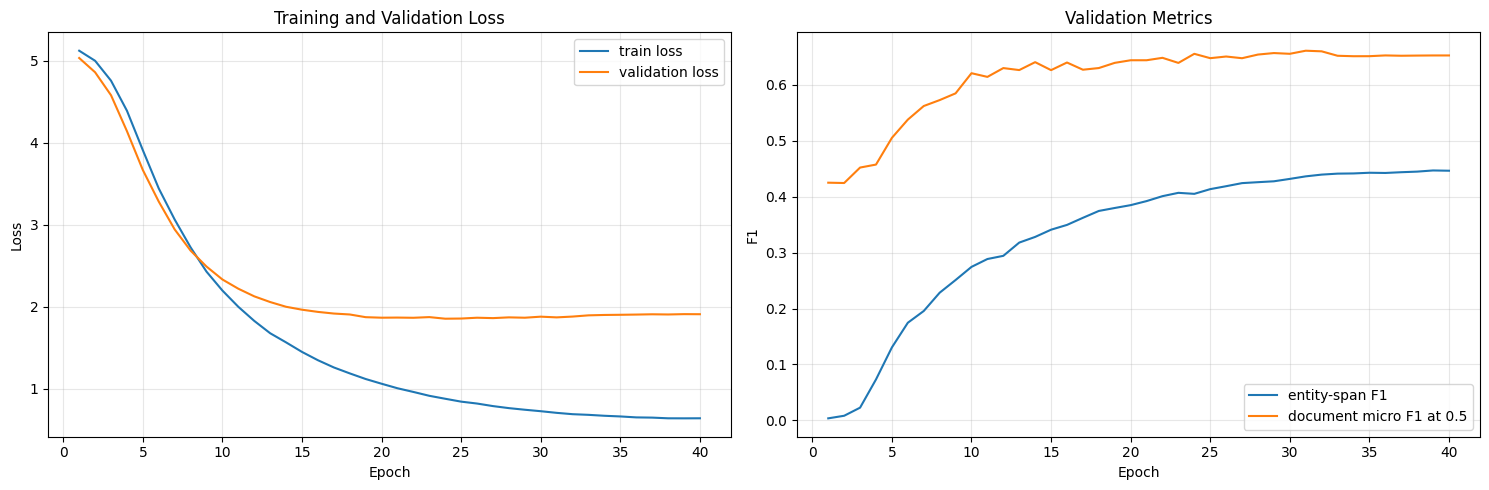

,epoch,train_loss,validation_loss,validation_entity_span_f1,validation_document_micro_f1_at_0_5,validation_selection_score,learning_rate
0,1,5.119724,5.030910,0.003672,0.424973,0.214323,0.000013
1,2,4.997130,4.857073,0.008288,0.424390,0.216339,0.000025
2,3,4.754755,4.577624,0.022770,0.452019,0.237394,0.000038
3,4,4.388951,4.140206,0.073213,0.457364,0.265289,0.000050
4,5,3.908036,3.666429,0.130510,0.505155,0.317832,0.000049
5,6,3.442141,3.282036,0.174579,0.537716,0.356148,0.000047
6,7,3.063631,2.943194,0.195573,0.562034,0.378804,0.000046
7,8,2.724790,2.685120,0.228268,0.572635,0.400451,0.000044
8,9,2.429037,2.490858,0.250948,0.584682,0.417815,0.000043
9,10,2.198680,2.333488,0.274441,0.620690,0.447565,0.000042


In [ ]:
# Visualize learning dynamics on the validation split
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(history['epoch'], history['train_loss'], label='train loss')
axes[0].plot(history['epoch'], history['validation_loss'], label='validation loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history['epoch'], history['validation_entity_span_f1'], label='entity-span F1')
axes[1].plot(history['epoch'], history['validation_document_micro_f1_at_0_5'], label='document micro F1 at 0.5')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('F1')
axes[1].set_title('Validation Metrics')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

display(history)


## Final Evaluation on the Untouched Test Split

This cell is run **after** the validation-selected checkpoint has been loaded. Per-label classification thresholds are tuned on validation data and then frozen. The test metrics printed below are the only final generalization estimates produced by this notebook.


In [ ]:
# Tune classification thresholds on validation data only
validation_collected = collect_evaluation_outputs(model, validation_dataloader)
classification_thresholds = tune_thresholds(
    validation_collected['document_true'],
    validation_collected['document_logits'],
)

threshold_table = pd.DataFrame({
    'relation_type': characteristic_names,
    'validation_selected_threshold': classification_thresholds,
})
display(threshold_table)

# Evaluate the frozen model and frozen thresholds once on the untouched test split
test_collected = collect_evaluation_outputs(model, test_dataloader)
test_metrics = summarise_evaluation(test_collected, classification_thresholds)

metrics_table = pd.DataFrame({
    'metric': [
        'Test loss',
        'BIO token macro F1 (all labels)',
        'BIO token macro F1 (entity labels only)',
        'Entity-span F1',
        'Document micro F1',
        'Document macro F1',
    ],
    'value': [
        test_metrics['loss'],
        test_metrics['bio_token_macro_f1_all_labels'],
        test_metrics['bio_token_macro_f1_entity_labels'],
        test_metrics['entity_span_f1'],
        test_metrics['document_micro_f1'],
        test_metrics['document_macro_f1'],
    ],
})
display(metrics_table.style.format({'value': '{:.4f}'}))


,relation_type,validation_selected_threshold
0,WORKPLACE,0.10
1,ALTERNATIVE_NAME,0.10
2,WORKS_AS,0.10
3,PARTICIPANT_IN,0.25
4,POINT_IN_TIME,0.10
5,TAKES_PLACE_IN,0.20
6,HEADQUARTERED_IN,0.25
7,ORIGINS_FROM,0.15
8,LOCATED_IN,0.45
9,AGENT,0.40


,metric,value
0,Test loss,1.7213
1,BIO token macro F1 (all labels),0.4685
2,BIO token macro F1 (entity labels only),0.4646
3,Entity-span F1,0.4260
4,Document micro F1,0.7534
5,Document macro F1,0.6408


In [ ]:
# Per-label document classification report on the final test split
print(classification_report(
    test_collected['document_true'],
    test_metrics['document_predictions'],
    target_names=characteristic_names,
    zero_division=0,
))

print('Entity-span classification report:')
print(seqeval_classification_report(
    test_collected['token_true_sequences'],
    test_collected['token_pred_sequences'],
    zero_division=0,
))


                    precision    recall  f1-score   support

         WORKPLACE       0.86      1.00      0.92        96
  ALTERNATIVE_NAME       1.00      1.00      1.00       112
          WORKS_AS       0.95      1.00      0.97       106
    PARTICIPANT_IN       0.95      0.96      0.96       103
     POINT_IN_TIME       0.74      1.00      0.85        83
    TAKES_PLACE_IN       0.73      0.94      0.82        81
  HEADQUARTERED_IN       0.78      0.98      0.87        84
      ORIGINS_FROM       0.68      0.97      0.80        75
        LOCATED_IN       0.77      0.67      0.72        73
             AGENT       0.65      0.81      0.72        62
            AGE_IS       0.72      0.94      0.81        77
         HAS_CAUSE       0.61      0.49      0.54        47
          PRODUCES       0.51      0.72      0.60        29
      AWARDED_WITH       0.81      0.81      0.81        21
           PART_OF       0.41      0.68      0.51        31
       IDEOLOGY_OF       0.35      0.64

## Qualitative Inference

The following example illustrates the format of the two outputs. The document-level probabilities are model confidence scores, not evidence that every relation type is present. Interpret them alongside the final quantitative evaluation rather than as standalone factual claims.


In [ ]:
def predict_document(model, text_words):
    model.eval()
    encoded = tokenizer(
        text_words,
        is_split_into_words=True,
        truncation=True,
        padding='max_length',
        max_length=MAX_LENGTH,
        return_tensors='pt',
    )
    word_ids = encoded.word_ids(batch_index=0)
    encoded = {key: value.to(device) for key, value in encoded.items()}

    with torch.no_grad():
        outputs = model(
            input_ids=encoded['input_ids'],
            attention_mask=encoded['attention_mask'],
            token_type_ids=encoded.get('token_type_ids'),
        )

    document_probabilities = torch.sigmoid(outputs['document_logits'])[0].cpu().numpy()
    token_predictions = outputs['token_logits'].argmax(dim=-1)[0].cpu().tolist()

    token_output = []
    previous_word_id = None
    for token_index, word_id in enumerate(word_ids):
        if word_id is None or word_id == previous_word_id:
            continue
        token_output.append((text_words[word_id], id2label[token_predictions[token_index]]))
        previous_word_id = word_id

    relation_output = pd.DataFrame({
        'relation_type': characteristic_names,
        'probability': document_probabilities,
        'selected_at_validation_threshold': document_probabilities >= classification_thresholds,
    }).sort_values('probability', ascending=False)
    return token_output, relation_output

example_words = ['Иван', 'Иванов,', 'сотрудник', 'Газпрома,', 'полетел', 'в', 'Париж', '15', 'мая', '2023', 'года.']
entity_predictions, relation_predictions = predict_document(model, example_words)

print('Token-level BIO predictions:')
for word, label in entity_predictions:
    print(f'{word}: {label}')

print('\nTop document-level relation-type probabilities:')
display(relation_predictions.head(10))


Token-level BIO predictions:
Иван: B-PERSON
Иванов,: I-PERSON
сотрудник: B-PROFESSION
Газпрома,: I-PROFESSION
полетел: B-EVENT
в: I-EVENT
Париж: B-CITY
15: B-DATE
мая: I-DATE
2023: I-DATE
года.: I-DATE

Top document-level relation-type probabilities:


,relation_type,probability,selected_at_validation_threshold
10,AGE_IS,0.736960,True
2,WORKS_AS,0.682820,True
6,HEADQUARTERED_IN,0.671959,True
9,AGENT,0.646179,True
8,LOCATED_IN,0.602831,True
19,SUBEVENT_OF,0.581215,True
5,TAKES_PLACE_IN,0.551215,True
26,ABBREVIATION,0.548586,True
0,WORKPLACE,0.548387,True
4,POINT_IN_TIME,0.456378,True


## Conclusions

After executing the notebook, report the **final test metrics** from the final-evaluation section rather than the validation-learning-curve peaks. The experiment should be interpreted as a reproducible multi-task baseline for Russian information extraction.

Its central contribution is methodological: a single compact RuBERT encoder is trained jointly for token-level NER and document-level relation-type presence prediction. The principal limitations are the small dataset size, the use of a compact encoder, the conversion of a rich nested-information-extraction resource into flat BIO and document-level targets, and the absence of entity-pair relation-triple extraction.

Further work could compare a larger RuBERT encoder, nested-NER modelling, alternative task-weighting strategies, and a relation-extraction head that explicitly scores entity pairs.


## References

[1] [NEREL official repository](https://github.com/nerel-ds/nerel)

[2] [Loukachevitch et al. (2021), *NEREL: A Russian Dataset with Nested Named Entities, Relations and Events*](https://aclanthology.org/2021.ranlp-1.100/)

[3] [cointegrated/rubert-tiny2 model card](https://huggingface.co/cointegrated/rubert-tiny2)
